## RRF (Reciprocal Rank Fusion)

In [1]:
## Setup
import sys
import os
import json
import re
from dotenv import load_dotenv

# Dodaje folder nadrzędny do ścieżki aby widzieć folder 'backend'
sys.path.append(os.path.abspath(os.path.join('..')))

from backend.rag_engine import LaborLawRAG

# 1. Ładowanie pytań testowych
with open('test_questions.json', 'r', encoding='utf-8') as f:
    test_questions = json.load(f)

# 2. Ładowanie zmiennych środowiskowych (z podfolderu backend)
load_dotenv(os.path.join('..', 'backend', '.env'))

# 3. Inicjalizacja silnika
rag = LaborLawRAG()

# 4. Funkcja do normalizacji
def normalize_art(art_name):
    # Usuwa wszystko co nie jest literą lub cyfrą (np. nawiasy, kropki, spacje)
    return re.sub(r'[^a-z0-9]', '', str(art_name).lower())

In [2]:
def evaluate(rag_instance, test_data, limit=20):
    hits = {5: 0, 10: 0, 20: 0}
    mrr_sum = 0
    total = len(test_data)

    print(f"Testowanie {total} pytań...")

    for item in test_data:
        query = item['question']
        expected = normalize_art(item['expected_art'])
        
        # Pobiera tylko kontekst
        _, sources = rag_instance.get_context(query, limit=limit)
        normalized_sources = [normalize_art(s) for s in sources]

        # Oblicza Recall@K
        for k in [5, 10, 20]:
            if expected in normalized_sources[:k]:
                hits[k] += 1
        
        # Oblicza MRR
        if expected in normalized_sources:
            rank = normalized_sources.index(expected) + 1
            mrr_sum += 1 / rank

    return {
        "R@5": round(hits[5]/total, 3),
        "R@10": round(hits[10]/total, 3),
        "R@20": round(hits[20]/total, 3),
        "MRR": round(mrr_sum/total, 3)
    }

In [3]:
results = {}
# Sprawdza różne proporcje: 0.0 (tylko słowa) -> 1.0 (tylko sens)
alphas = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

for a in alphas:
    rag.alpha = a
    score = evaluate(rag, test_questions)
    results[a] = score
    print(f"Alpha {a}: {score}")

Testowanie 50 pytań...
Alpha 0.0: {'R@5': 0.28, 'R@10': 0.58, 'R@20': 0.92, 'MRR': 0.183}
Testowanie 50 pytań...
Alpha 0.05: {'R@5': 0.28, 'R@10': 0.58, 'R@20': 0.92, 'MRR': 0.184}
Testowanie 50 pytań...
Alpha 0.1: {'R@5': 0.28, 'R@10': 0.56, 'R@20': 0.92, 'MRR': 0.184}
Testowanie 50 pytań...
Alpha 0.15: {'R@5': 0.28, 'R@10': 0.56, 'R@20': 0.92, 'MRR': 0.182}
Testowanie 50 pytań...
Alpha 0.2: {'R@5': 0.28, 'R@10': 0.56, 'R@20': 0.92, 'MRR': 0.184}
Testowanie 50 pytań...
Alpha 0.25: {'R@5': 0.28, 'R@10': 0.58, 'R@20': 0.92, 'MRR': 0.184}
Testowanie 50 pytań...
Alpha 0.3: {'R@5': 0.28, 'R@10': 0.58, 'R@20': 0.92, 'MRR': 0.183}
Testowanie 50 pytań...
Alpha 0.35: {'R@5': 0.28, 'R@10': 0.56, 'R@20': 0.92, 'MRR': 0.183}
Testowanie 50 pytań...
Alpha 0.4: {'R@5': 0.28, 'R@10': 0.56, 'R@20': 0.92, 'MRR': 0.183}
Testowanie 50 pytań...
Alpha 0.45: {'R@5': 0.28, 'R@10': 0.56, 'R@20': 0.92, 'MRR': 0.183}
Testowanie 50 pytań...
Alpha 0.5: {'R@5': 0.28, 'R@10': 0.56, 'R@20': 0.92, 'MRR': 0.183}
Testo

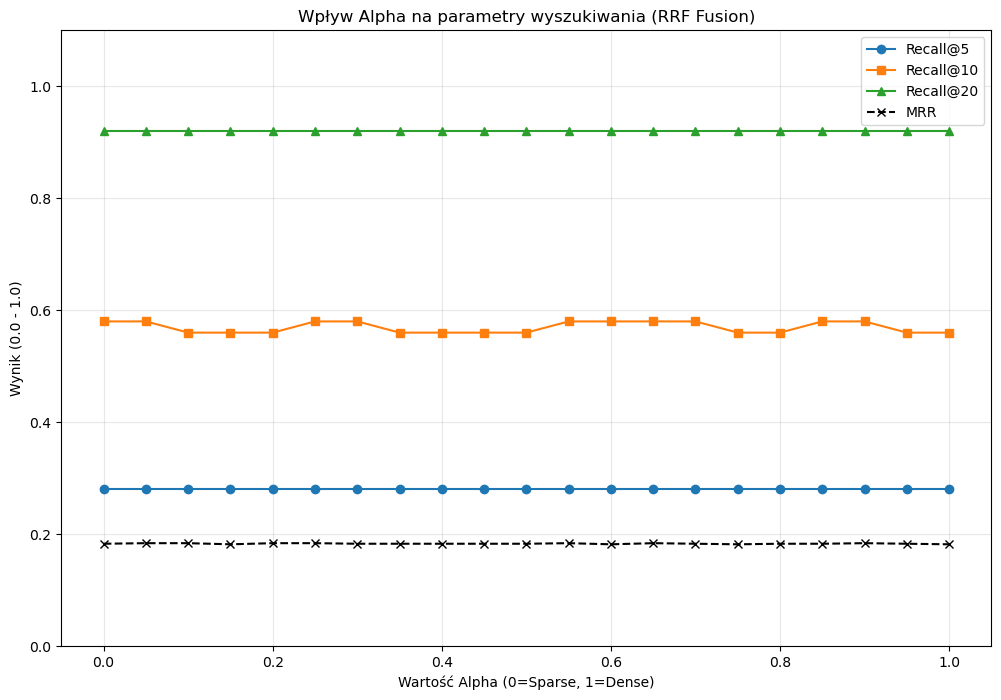

In [12]:
import matplotlib.pyplot as plt

# Przygotowanie danych z wyników
alphas = list(results.keys())
r5 = [results[a]['R@5'] for a in alphas]
r10 = [results[a]['R@10'] for a in alphas]
r20 = [results[a]['R@20'] for a in alphas]
mrr = [results[a]['MRR'] for a in alphas]

plt.figure(figsize=(12, 8))
plt.plot(alphas, r5, label='Recall@5', marker='o')
plt.plot(alphas, r10, label='Recall@10', marker='s')
plt.plot(alphas, r20, label='Recall@20', marker='^')
plt.plot(alphas, mrr, label='MRR', linestyle='--', color='black', marker='x')

plt.title('Wpływ Alpha na parametry wyszukiwania (RRF Fusion)')
plt.xlabel('Wartość Alpha (0=Sparse, 1=Dense)')
plt.ylabel('Wynik (0.0 - 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

plt.savefig('hybrid_search_benchmark_rrf.png')

## DBS / Weighted Sum (Distribution Based Score)

In [1]:
## Setup
import sys
import os
import json
import re
from dotenv import load_dotenv

# Dodaje folder nadrzędny do ścieżki aby widzieć folder 'backend'
sys.path.append(os.path.abspath(os.path.join('..')))

from backend.rag_engine import LaborLawRAG

# 1. Ładowanie pytań testowych
with open('test_questions.json', 'r', encoding='utf-8') as f:
    test_questions = json.load(f)

# 2. Ładowanie zmiennych środowiskowych (z podfolderu backend)
load_dotenv(os.path.join('..', 'backend', '.env'))

# 3. Inicjalizacja silnika
rag = LaborLawRAG()

# 4. Funkcja do normalizacji
def normalize_art(art_name):
    # Usuwa wszystko co nie jest literą lub cyfrą (np. nawiasy, kropki, spacje)
    return re.sub(r'[^a-z0-9]', '', str(art_name).lower())


def evaluate(rag_instance, test_data, limit=20):
    hits = {5: 0, 10: 0, 20: 0}
    mrr_sum = 0
    total = len(test_data)

    print(f"Testowanie {total} pytań...")

    for item in test_data:
        query = item['question']
        expected = normalize_art(item['expected_art'])
        
        # Pobiera tylko kontekst
        _, sources = rag_instance.get_context(query, limit=limit)
        normalized_sources = [normalize_art(s) for s in sources]

        # Oblicza Recall@K
        for k in [5, 10, 20]:
            if expected in normalized_sources[:k]:
                hits[k] += 1
        
        # Oblicza MRR
        if expected in normalized_sources:
            rank = normalized_sources.index(expected) + 1
            mrr_sum += 1 / rank

    return {
        "R@5": round(hits[5]/total, 3),
        "R@10": round(hits[10]/total, 3),
        "R@20": round(hits[20]/total, 3),
        "MRR": round(mrr_sum/total, 3)
    }


results = {}
# Sprawdza różne proporcje: 0.0 (tylko słowa) -> 1.0 (tylko sens)
alphas = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

for a in alphas:
    rag.alpha = a
    score = evaluate(rag, test_questions)
    results[a] = score
    print(f"Alpha {a}: {score}")

Testowanie 50 pytań...
Alpha 0.0: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.05: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.1: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.15: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.2: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.25: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.3: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.35: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.4: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.45: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.5: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testo

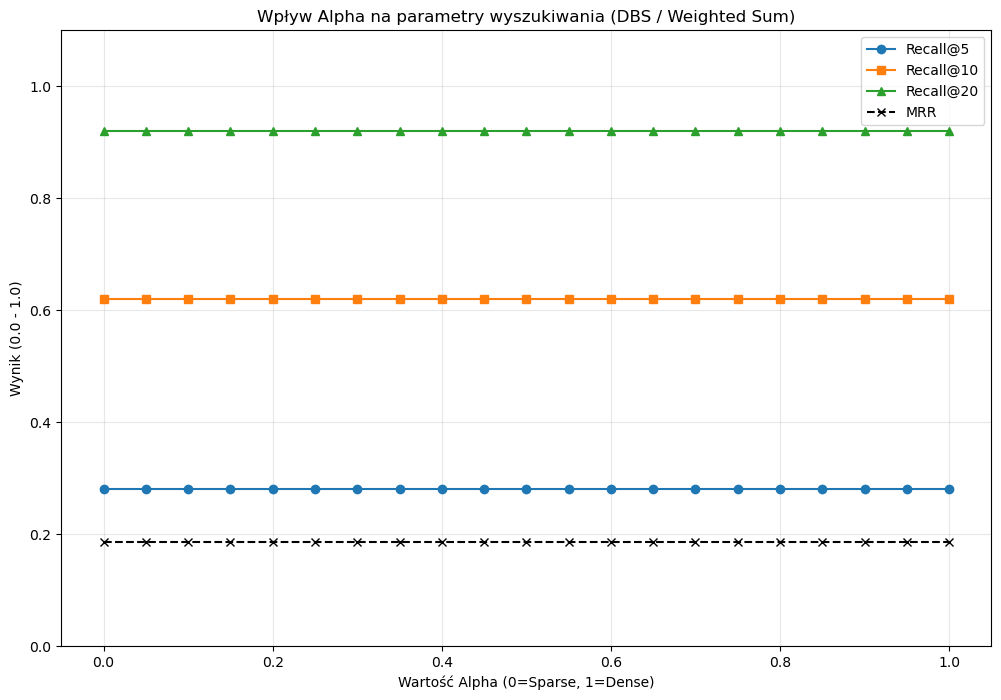

In [5]:
import matplotlib.pyplot as plt

# Przygotowanie danych z wyników
alphas = list(results.keys())
r5 = [results[a]['R@5'] for a in alphas]
r10 = [results[a]['R@10'] for a in alphas]
r20 = [results[a]['R@20'] for a in alphas]
mrr = [results[a]['MRR'] for a in alphas]

plt.figure(figsize=(12, 8))
plt.plot(alphas, r5, label='Recall@5', marker='o')
plt.plot(alphas, r10, label='Recall@10', marker='s')
plt.plot(alphas, r20, label='Recall@20', marker='^')
plt.plot(alphas, mrr, label='MRR', linestyle='--', color='black', marker='x')

plt.title('Wpływ Alpha na parametry wyszukiwania (DBS / Weighted Sum)')
plt.xlabel('Wartość Alpha (0=Sparse, 1=Dense)')
plt.ylabel('Wynik (0.0 - 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

plt.savefig('hybrid_search_benchmark_dbs.png')

## DBS (active weights)

In [1]:
## Setup
import sys
import os
import json
import re
from dotenv import load_dotenv

# Dodaje folder nadrzędny do ścieżki aby widzieć folder 'backend'
sys.path.append(os.path.abspath(os.path.join('..')))

from backend.rag_engine import LaborLawRAG

# 1. Ładowanie pytań testowych
with open('test_questions.json', 'r', encoding='utf-8') as f:
    test_questions = json.load(f)

# 2. Ładowanie zmiennych środowiskowych (z podfolderu backend)
load_dotenv(os.path.join('..', 'backend', '.env'))

# 3. Inicjalizacja silnika
rag = LaborLawRAG()

# 4. Funkcja do normalizacji
def normalize_art(art_name):
    # Usuwa wszystko co nie jest literą lub cyfrą (np. nawiasy, kropki, spacje)
    return re.sub(r'[^a-z0-9]', '', str(art_name).lower())


def evaluate(rag_instance, test_data, limit=20):
    hits = {5: 0, 10: 0, 20: 0}
    mrr_sum = 0
    total = len(test_data)

    print(f"Testowanie {total} pytań...")

    for item in test_data:
        query = item['question']
        expected = normalize_art(item['expected_art'])
        
        # Pobiera tylko kontekst
        _, sources = rag_instance.get_context(query, limit=limit)
        normalized_sources = [normalize_art(s) for s in sources]

        # Oblicza Recall@K
        for k in [5, 10, 20]:
            if expected in normalized_sources[:k]:
                hits[k] += 1
        
        # Oblicza MRR
        if expected in normalized_sources:
            rank = normalized_sources.index(expected) + 1
            mrr_sum += 1 / rank

    return {
        "R@5": round(hits[5]/total, 3),
        "R@10": round(hits[10]/total, 3),
        "R@20": round(hits[20]/total, 3),
        "MRR": round(mrr_sum/total, 3)
    }


results = {}
# Sprawdza różne proporcje: 0.0 (tylko słowa) -> 1.0 (tylko sens)
alphas = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

for a in alphas:
    rag.alpha = a
    score = evaluate(rag, test_questions)
    results[a] = score
    print(f"Alpha {a}: {score}")

Testowanie 50 pytań...
Alpha 0.0: {'R@5': 0.3, 'R@10': 0.5, 'R@20': 0.78, 'MRR': 0.158}
Testowanie 50 pytań...
Alpha 0.05: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.1: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.15: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.2: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.25: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.3: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.35: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.4: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.45: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowanie 50 pytań...
Alpha 0.5: {'R@5': 0.28, 'R@10': 0.62, 'R@20': 0.92, 'MRR': 0.186}
Testowa

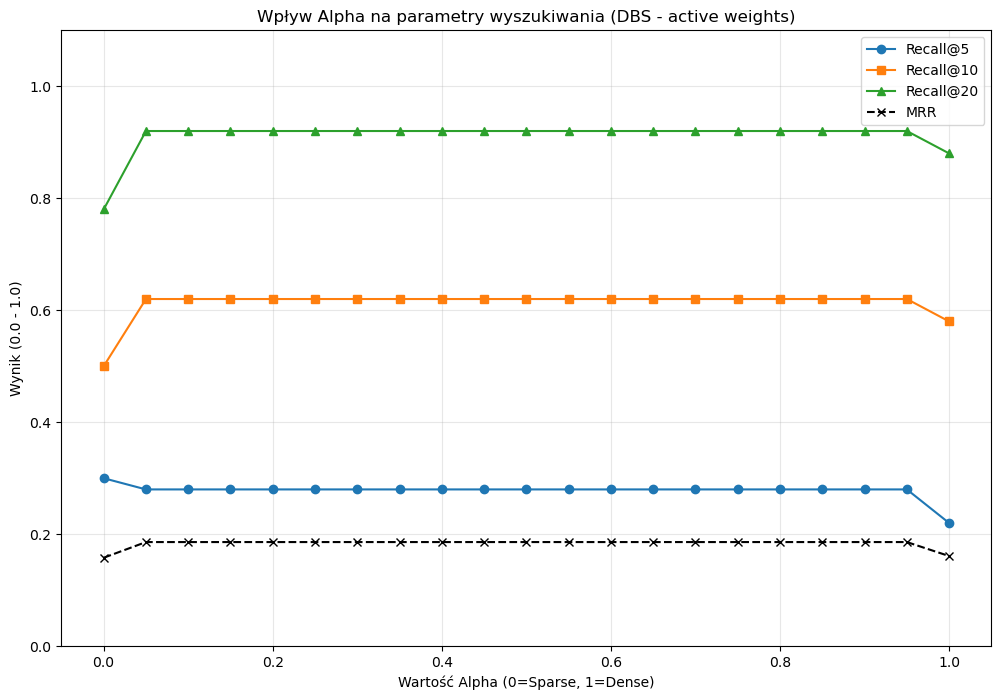

In [3]:
import matplotlib.pyplot as plt

# Przygotowanie danych z wyników
alphas = list(results.keys())
r5 = [results[a]['R@5'] for a in alphas]
r10 = [results[a]['R@10'] for a in alphas]
r20 = [results[a]['R@20'] for a in alphas]
mrr = [results[a]['MRR'] for a in alphas]

plt.figure(figsize=(12, 8))
plt.plot(alphas, r5, label='Recall@5', marker='o')
plt.plot(alphas, r10, label='Recall@10', marker='s')
plt.plot(alphas, r20, label='Recall@20', marker='^')
plt.plot(alphas, mrr, label='MRR', linestyle='--', color='black', marker='x')

plt.title('Wpływ Alpha na parametry wyszukiwania (DBS - active weights)')
plt.xlabel('Wartość Alpha (0=Sparse, 1=Dense)')
plt.ylabel('Wynik (0.0 - 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

plt.savefig('hybrid_search_benchmark_dbs_active_weights.png')

## Reranker (Cross-Encoder)

In [1]:
## Setup
import sys
import os
import json
import re
from dotenv import load_dotenv

# Dodaje folder nadrzędny do ścieżki aby widzieć folder 'backend'
sys.path.append(os.path.abspath(os.path.join('..')))

from backend.rag_engine import LaborLawRAG

# 1. Ładowanie pytań testowych
with open('test_questions.json', 'r', encoding='utf-8') as f:
    test_questions = json.load(f)

# 2. Ładowanie zmiennych środowiskowych (z podfolderu backend)
load_dotenv(os.path.join('..', 'backend', '.env'))

# 3. Inicjalizacja silnika
rag = LaborLawRAG()

# 4. Funkcja do normalizacji
def normalize_art(art_name):
    # Usuwa wszystko co nie jest literą lub cyfrą (np. nawiasy, kropki, spacje)
    return re.sub(r'[^a-z0-9]', '', str(art_name).lower())


def evaluate(rag_instance, test_data, limit=20):
    hits = {5: 0, 10: 0, 20: 0}
    mrr_sum = 0
    total = len(test_data)

    print(f"Testowanie {total} pytań...")

    for item in test_data:
        query = item['question']
        expected = normalize_art(item['expected_art'])
        
        # Pobiera tylko kontekst
        _, sources = rag_instance.get_context(query, limit=limit)
        normalized_sources = [normalize_art(s) for s in sources]

        # Oblicza Recall@K
        for k in [5, 10, 20]:
            if expected in normalized_sources[:k]:
                hits[k] += 1
        
        # Oblicza MRR
        if expected in normalized_sources:
            rank = normalized_sources.index(expected) + 1
            mrr_sum += 1 / rank

    return {
        "R@5": round(hits[5]/total, 3),
        "R@10": round(hits[10]/total, 3),
        "R@20": round(hits[20]/total, 3),
        "MRR": round(mrr_sum/total, 3)
    }


results = {}
# Sprawdza różne proporcje: 0.0 (tylko słowa) -> 1.0 (tylko sens)
alphas = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

for a in alphas:
    rag.alpha = a
    score = evaluate(rag, test_questions)
    results[a] = score
    print(f"Alpha {a}: {score}")


Testowanie 50 pytań...
DEBUG Scores: [0.00247164 0.00242951 0.00473354]
DEBUG Scores: [0.97500426 0.09407866 0.9302859 ]
DEBUG Scores: [0.9989592  0.33337086 0.7838425 ]
DEBUG Scores: [0.13756451 0.63282907 0.8574691 ]
DEBUG Scores: [0.99907947 0.10307813 0.97790194]
DEBUG Scores: [0.9984767  0.87063485 0.01917566]
DEBUG Scores: [0.99735594 0.9986601  0.95540684]
DEBUG Scores: [0.13077523 0.9925823  0.96762776]
DEBUG Scores: [9.9912602e-01 5.0540990e-01 3.8682326e-04]
DEBUG Scores: [0.99952865 0.02965165 0.01246541]
DEBUG Scores: [0.46554217 0.00560912 0.96802676]
DEBUG Scores: [0.79573077 0.7967526  0.7302225 ]
DEBUG Scores: [0.9985323  0.08832102 0.2999269 ]
DEBUG Scores: [0.25985885 0.984985   0.6748197 ]
DEBUG Scores: [0.9823611  0.12824397 0.0153218 ]
DEBUG Scores: [0.9944629  0.25360322 0.14666659]
DEBUG Scores: [0.99848723 0.99820864 0.98736274]
DEBUG Scores: [6.1949086e-04 1.9011617e-04 2.9072267e-05]
DEBUG Scores: [0.9981704  0.99986994 0.99719185]
DEBUG Scores: [0.9977647  0

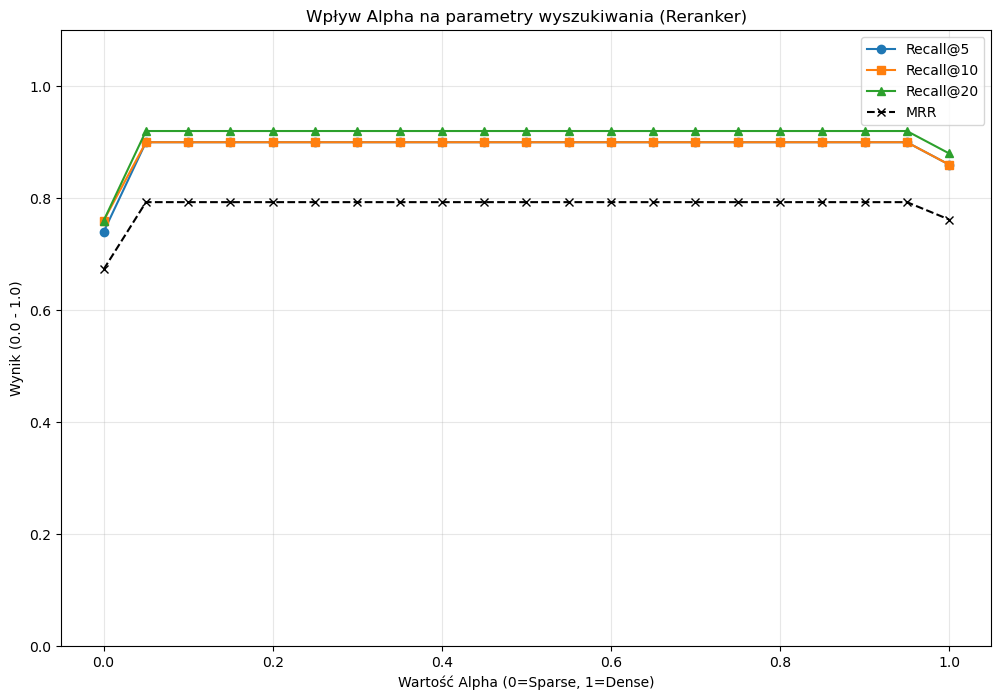

In [3]:
import matplotlib.pyplot as plt

# Przygotowanie danych z wyników
alphas = list(results.keys())
r5 = [results[a]['R@5'] for a in alphas]
r10 = [results[a]['R@10'] for a in alphas]
r20 = [results[a]['R@20'] for a in alphas]
mrr = [results[a]['MRR'] for a in alphas]

plt.figure(figsize=(12, 8))
plt.plot(alphas, r5, label='Recall@5', marker='o')
plt.plot(alphas, r10, label='Recall@10', marker='s')
plt.plot(alphas, r20, label='Recall@20', marker='^')
plt.plot(alphas, mrr, label='MRR', linestyle='--', color='black', marker='x')

plt.title('Wpływ Alpha na parametry wyszukiwania (Reranker)')
plt.xlabel('Wartość Alpha (0=Sparse, 1=Dense)')
plt.ylabel('Wynik (0.0 - 1.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.1)

plt.savefig('hybrid_search_benchmark_reranker.png')

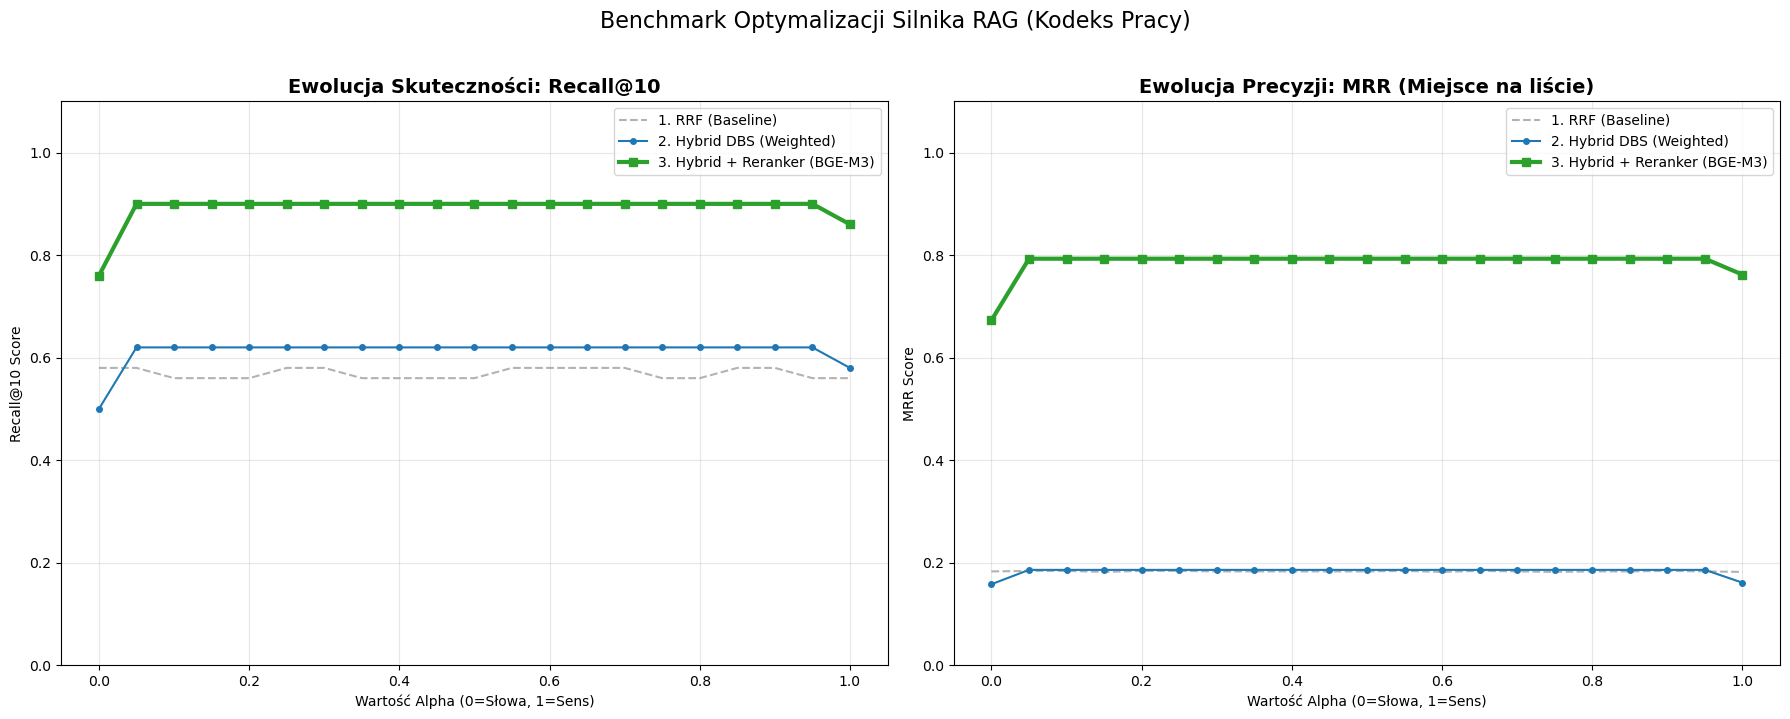

In [5]:
import matplotlib.pyplot as plt

# 1. Osie X (Alpha)
alphas = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

# 2. Dane Historyczne (z poprzednich sesji)

# RRF (Reciprocal Rank Fusion)
rrf_mrr = [0.183, 0.184, 0.184, 0.182, 0.184, 0.184, 0.183, 0.183, 0.183, 0.183, 0.183, 0.184, 0.182, 0.184, 0.183, 0.182, 0.183, 0.183, 0.184, 0.183, 0.182]
rrf_r10 = [0.58, 0.58, 0.56, 0.56, 0.56, 0.58, 0.58, 0.56, 0.56, 0.56, 0.56, 0.58, 0.58, 0.58, 0.58, 0.56, 0.56, 0.58, 0.58, 0.56, 0.56]

# DBS (Active Weights - Hybrid)
dbs_mrr = [0.158] + [0.186]*19 + [0.161]
dbs_r10 = [0.50] + [0.62]*19 + [0.58]

# 3. Dane z bieżącej sesji (Reranker)
### pobiera je bezpośrednio ze słownika 'results'
reranker_mrr = [results[a]['MRR'] for a in alphas]
reranker_r10 = [results[a]['R@10'] for a in alphas]

# WYKRES
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Subplot 1: Recall@10
ax1.plot(alphas, rrf_r10, label='1. RRF (Baseline)', color='gray', linestyle='--', alpha=0.6)
ax1.plot(alphas, dbs_r10, label='2. Hybrid DBS (Weighted)', color='#1f77b4', marker='o', markersize=4)
ax1.plot(alphas, reranker_r10, label='3. Hybrid + Reranker (BGE-M3)', color='#2ca02c', linewidth=3, marker='s', markersize=6)

ax1.set_title('Ewolucja Skuteczności: Recall@10', fontsize=14, fontweight='bold')
ax1.set_xlabel('Wartość Alpha (0=Słowa, 1=Sens)')
ax1.set_ylabel('Recall@10 Score')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.1)

# Subplot 2: MRR (Precyzja)
ax2.plot(alphas, rrf_mrr, label='1. RRF (Baseline)', color='gray', linestyle='--', alpha=0.6)
ax2.plot(alphas, dbs_mrr, label='2. Hybrid DBS (Weighted)', color='#1f77b4', marker='o', markersize=4)
ax2.plot(alphas, reranker_mrr, label='3. Hybrid + Reranker (BGE-M3)', color='#2ca02c', linewidth=3, marker='s', markersize=6)

ax2.set_title('Ewolucja Precyzji: MRR (Miejsce na liście)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Wartość Alpha (0=Słowa, 1=Sens)')
ax2.set_ylabel('MRR Score')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.1)

plt.suptitle('Benchmark Optymalizacji Silnika RAG (Kodeks Pracy)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('rag_final_comparison_benchmark.png', bbox_inches='tight')